In [1]:
# ============================================================
# CELL 1 — Imports and load the processed data
# ============================================================
# These 4 files came straight out of your 9-cell data
# processing notebook. We don't reload the raw CSV or repeat
# any cleaning/encoding here — that work is already done.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)
from xgboost import XGBClassifier

X_early = pd.read_csv("X_early.csv")
y_early = pd.read_csv("y_early.csv").squeeze()   # squeeze turns single-column df into a Series

X_mid = pd.read_csv("X_mid.csv")
y_mid = pd.read_csv("y_mid.csv").squeeze()

print("=== EARLY ===")
print(f"X_early shape: {X_early.shape}")
print(f"y_early at-risk %: {y_early.mean()*100:.1f}%")

print("\n=== MID-SEMESTER ===")
print(f"X_mid shape: {X_mid.shape}")
print(f"y_mid at-risk %: {y_mid.mean()*100:.1f}%")

print("\nFiles loaded successfully. Ready to train.")

=== EARLY ===
X_early shape: (395, 42)
y_early at-risk %: 32.9%

=== MID-SEMESTER ===
X_mid shape: (395, 43)
y_mid at-risk %: 32.9%

Files loaded successfully. Ready to train.


In [2]:
# ============================================================
# CELL 2 — Reusable train + tune + evaluate function
# ============================================================
# We write this ONCE and call it twice — once per feature set.
# This guarantees both models are built and judged in exactly
# the same fair way, so the comparison between them is honest.

def train_and_evaluate(X, y, model_name="model", run_gridsearch=True):
    """
    Splits data, scales it, trains an XGBoost model, finds the
    best decision threshold, optionally tunes hyperparameters
    with GridSearchCV, and prints a full evaluation report.
    """

    # --- Step 1: split into study group (80%) and quiz group (20%) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # --- Step 2: scale every feature onto a comparable range ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # --- Step 3: dynamic class-imbalance weighting ---
    # (computed from the actual data, not hardcoded — this
    # mirrors the improvement we discussed earlier)
    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    # --- Step 4: baseline model + 5-fold cross-validation ---
    baseline_model = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ratio, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    cv_scores = cross_val_score(baseline_model, X_train_scaled, y_train,
                                 cv=5, scoring='f1')
    print(f"\n[{model_name}] Baseline 5-fold CV F1 scores: {cv_scores.round(3)}")
    print(f"[{model_name}] Average CV F1: {cv_scores.mean():.3f}")

    # --- Step 5: hyperparameter tuning with GridSearchCV ---
    if run_gridsearch:
        param_grid = {
            'n_estimators'    : [200, 300, 400],
            'max_depth'       : [3, 4, 5],
            'learning_rate'   : [0.01, 0.05, 0.1],
            'subsample'       : [0.7, 0.8],
            'colsample_bytree': [0.7, 0.8],
        }
        grid_search = GridSearchCV(
            XGBClassifier(scale_pos_weight=ratio, random_state=42,
                          eval_metric='logloss', verbosity=0),
            param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
        )
        print(f"[{model_name}] Running GridSearch (~30-60s)...")
        grid_search.fit(X_train_scaled, y_train)
        model = grid_search.best_estimator_
        print(f"[{model_name}] Best params: {grid_search.best_params_}")
        print(f"[{model_name}] Best CV F1 : {grid_search.best_score_:.3f}")
    else:
        model = baseline_model
        model.fit(X_train_scaled, y_train)

    # --- Step 6: find the best decision threshold on the test set ---
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    thresholds = np.arange(0.20, 0.70, 0.01)
    f1s = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
           for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    y_pred = (y_prob >= best_t).astype(int)

    # --- Step 7: print the full report ---
    print(f"\n========== {model_name.upper()} — FINAL REPORT ==========")
    print(f"Best threshold: {best_t:.2f}")
    print(classification_report(y_test, y_pred, target_names=['Safe', 'At-Risk']))

    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc_auc:.3f}")

    # --- Step 8: confusion matrix ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Safe', 'Pred At-Risk'],
                yticklabels=['Actual Safe', 'Actual At-Risk'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150)
    plt.show()

    return {
        'model': model, 'scaler': scaler, 'threshold': best_t,
        'roc_auc': roc_auc, 'cv_f1': cv_scores.mean(),
        'feature_names': X.columns.tolist(),
        'X_test_scaled': X_test_scaled, 'y_test': y_test, 'y_prob': y_prob
    }

print("Training function ready.")

Training function ready.



[early] Baseline 5-fold CV F1 scores: [0.359 0.188 0.409 0.455 0.341]
[early] Average CV F1: 0.350
[early] Running GridSearch (~30-60s)...
[early] Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.7}
[early] Best CV F1 : 0.450

========== EARLY — FINAL REPORT ==========
Best threshold: 0.52
              precision    recall  f1-score   support

        Safe       0.81      0.87      0.84        53
     At-Risk       0.68      0.58      0.62        26

    accuracy                           0.77        79
   macro avg       0.74      0.72      0.73        79
weighted avg       0.77      0.77      0.77        79

ROC-AUC: 0.742


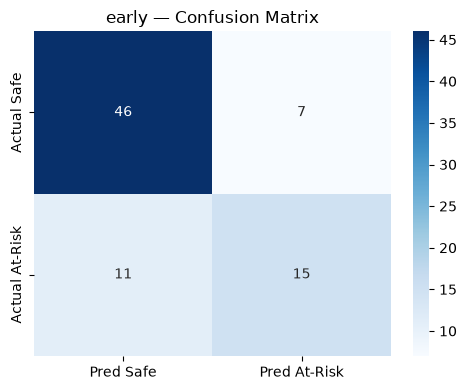

In [3]:
# ============================================================
# CELL 3 — Train the EARLY model (no grades at all)
# ============================================================
# Usable from week 1 of the semester. This is the model your
# whole project description centers around.

early_results = train_and_evaluate(X_early, y_early, model_name="early")


[mid_semester] Baseline 5-fold CV F1 scores: [0.634 0.632 0.816 0.766 0.766]
[mid_semester] Average CV F1: 0.723
[mid_semester] Running GridSearch (~30-60s)...
[mid_semester] Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
[mid_semester] Best CV F1 : 0.765

========== MID_SEMESTER — FINAL REPORT ==========
Best threshold: 0.46
              precision    recall  f1-score   support

        Safe       0.98      0.79      0.88        53
     At-Risk       0.69      0.96      0.81        26

    accuracy                           0.85        79
   macro avg       0.84      0.88      0.84        79
weighted avg       0.88      0.85      0.85        79

ROC-AUC: 0.944


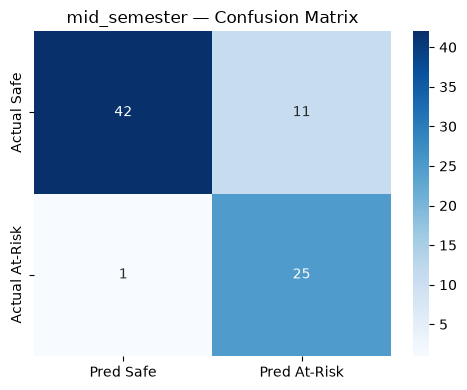

In [4]:
# ============================================================
# CELL 4 — Train the MID-SEMESTER model (includes G1)
# ============================================================
# Usable once the first grading period has happened.
# Same exact process as Cell 3, just different input data.

mid_results = train_and_evaluate(X_mid, y_mid, model_name="mid_semester")

================ COMPARISON ================
Metric                      Early    Mid-Semester
-------------------- ------------ ---------------
ROC-AUC                     0.742           0.944
CV F1                       0.350           0.723
Threshold                    0.52            0.46
Feature count                  42              43

ROC-AUC improvement from adding G1: +0.202


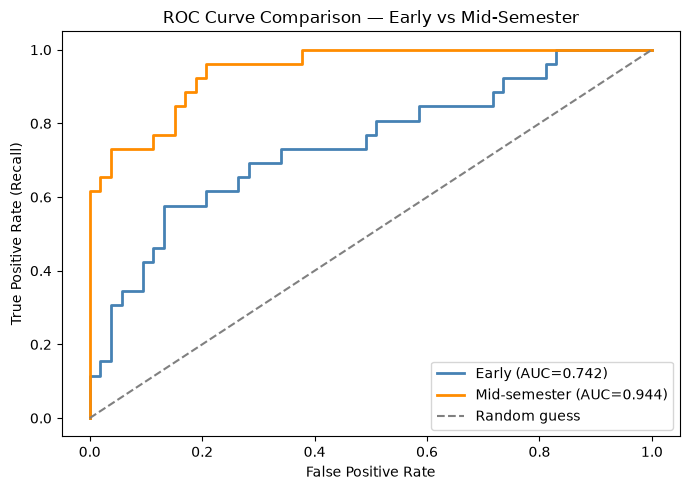

Saved: roc_comparison.png


In [5]:
# ============================================================
# CELL 5 — Compare early vs mid-semester models
# ============================================================

print("================ COMPARISON ================")
print(f"{'Metric':<20} {'Early':>12} {'Mid-Semester':>15}")
print(f"{'-'*20} {'-'*12} {'-'*15}")
print(f"{'ROC-AUC':<20} {early_results['roc_auc']:>12.3f} {mid_results['roc_auc']:>15.3f}")
print(f"{'CV F1':<20} {early_results['cv_f1']:>12.3f} {mid_results['cv_f1']:>15.3f}")
print(f"{'Threshold':<20} {early_results['threshold']:>12.2f} {mid_results['threshold']:>15.2f}")
print(f"{'Feature count':<20} {len(early_results['feature_names']):>12} {len(mid_results['feature_names']):>15}")

improvement = mid_results['roc_auc'] - early_results['roc_auc']
print(f"\nROC-AUC improvement from adding G1: +{improvement:.3f}")

# Plot both ROC curves on the same chart for a direct visual comparison
fpr_e, tpr_e, _ = roc_curve(early_results['y_test'], early_results['y_prob'])
fpr_m, tpr_m, _ = roc_curve(mid_results['y_test'], mid_results['y_prob'])

plt.figure(figsize=(7, 5))
plt.plot(fpr_e, tpr_e, label=f"Early (AUC={early_results['roc_auc']:.3f})", color='steelblue', lw=2)
plt.plot(fpr_m, tpr_m, label=f"Mid-semester (AUC={mid_results['roc_auc']:.3f})", color='darkorange', lw=2)
plt.plot([0,1],[0,1],'--',color='gray',label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison — Early vs Mid-Semester')
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()
print("Saved: roc_comparison.png")

In [6]:
# ============================================================
# CELL 6 — Save both trained models and scalers
# ============================================================
import joblib

joblib.dump(early_results['model'],  'failsafe_model_early.pkl')
joblib.dump(early_results['scaler'], 'failsafe_scaler_early.pkl')

joblib.dump(mid_results['model'],  'failsafe_model_mid.pkl')
joblib.dump(mid_results['scaler'], 'failsafe_scaler_mid.pkl')

print("Saved 4 model/scaler files:")
print("  failsafe_model_early.pkl,  failsafe_scaler_early.pkl")
print("  failsafe_model_mid.pkl,    failsafe_scaler_mid.pkl")

Saved 4 model/scaler files:
  failsafe_model_early.pkl,  failsafe_scaler_early.pkl
  failsafe_model_mid.pkl,    failsafe_scaler_mid.pkl


In [7]:
# ============================================================
# CELL 7 — Save feature lists and a combined config file
# ============================================================
import json

with open('feature_names_early.json', 'w') as f:
    json.dump(early_results['feature_names'], f)

with open('feature_names_mid.json', 'w') as f:
    json.dump(mid_results['feature_names'], f)

config = {
    'early': {
        'threshold'  : float(early_results['threshold']),
        'roc_auc'    : float(early_results['roc_auc']),
        'cv_f1'      : float(early_results['cv_f1']),
        'n_features' : len(early_results['feature_names']),
        'requires'   : 'No grades needed — usable from week 1'
    },
    'mid_semester': {
        'threshold'  : float(mid_results['threshold']),
        'roc_auc'    : float(mid_results['roc_auc']),
        'cv_f1'      : float(mid_results['cv_f1']),
        'n_features' : len(mid_results['feature_names']),
        'requires'   : 'G1 grade must exist — usable after first grading period'
    }
}
with open('model_config_two_tier.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved: feature_names_early.json, feature_names_mid.json, model_config_two_tier.json")
print(json.dumps(config, indent=2))

Saved: feature_names_early.json, feature_names_mid.json, model_config_two_tier.json
{
  "early": {
    "threshold": 0.5200000000000002,
    "roc_auc": 0.7423802612481858,
    "cv_f1": 0.35031482744897385,
    "n_features": 42,
    "requires": "No grades needed \u2014 usable from week 1"
  },
  "mid_semester": {
    "threshold": 0.46000000000000024,
    "roc_auc": 0.944121915820029,
    "cv_f1": 0.7227933426122203,
    "n_features": 43,
    "requires": "G1 grade must exist \u2014 usable after first grading period"
  }
}
